In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
if not os.path.exists('plots/'):
    os.mkdir('plots')


# Load Data 

In [23]:
#reference data
pressure1_ref = np.load('../data/p1.npy')
pressure8_ref = np.load('../data/p8.npy')

dtid=[1,8]
dts=[]

for e in dtid:
    ar=np.loadtxt("../data/fes{}.dat".format(e))
    ars=ar[:,2]
    ars=ars.reshape(257,257)
    dts.append(ars)

# expTM generated data pressure
gen_samples_pressure = np.load('../data/gen_samples_pressure_list_new.npy')


# expTM generated data temperatures
temperature_gen = []
# Load and stack each file using a loop
for i in range(1, 4):
    file_name = f'../data/gen_samples_lam{i}_temp.npy'
    temperature_gen.append(np.load(file_name))

# Figure3 (b)

In [20]:
p1_mean_ref = pressure1_ref.mean(axis=2)
p8_mean_ref = pressure8_ref.mean(axis=2)

p1_mean_gen = gen_samples_pressure[0,:,:,:].mean(axis=-1)
p8_mean_gen = gen_samples_pressure[-1,:,:,:].mean(axis=-1)

sbcmap=sns.color_palette("viridis_r", as_cmap=True)


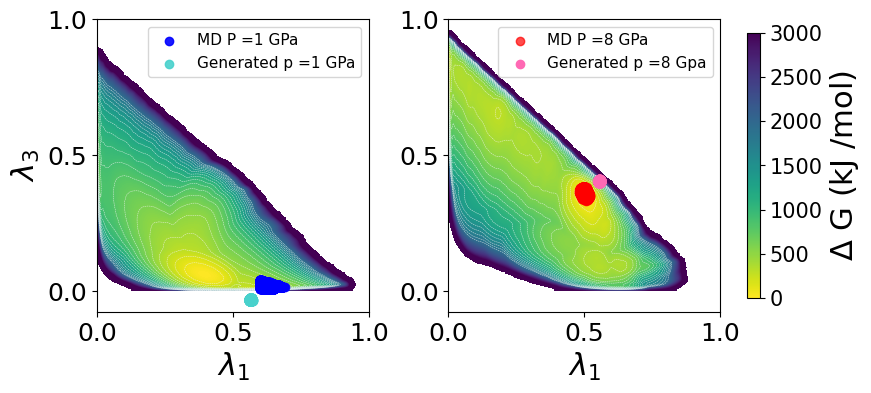

In [18]:
plt.figure(figsize=(8, 6))
levels = np.arange(0, 2000, 100)
fessave = []

for i in range(2):
    xy = np.arange(0, 257, 1) / 256
    extent = [xy[0], xy[-1], xy[0], xy[-1]]
    dt = dts[i]
    dt[dt >= 0] = np.inf
    dt = dt - np.min(dt)

    ax = plt.subplot(1, 2, i + 1)
    CS2 = ax.contour(dt, levels=levels, colors='whitesmoke', extent=extent, origin='lower', linestyles='dashed', linewidths=0.3)
    im = ax.imshow(dt, origin='lower', cmap=sbcmap, extent=extent, vmax=3000)

    if i == 0:
        ax.scatter(p1_mean_ref[:, 0], p1_mean_ref[:, 1], color='b', alpha=0.9, label="MD P ={} GPa".format(dtid[i]), zorder=3)
        ax.scatter(p1_mean_gen[:, 0], p1_mean_gen[:, 1], color='mediumturquoise', alpha=0.9, label="Generated p ={} GPa".format(dtid[i]), zorder=3)
    elif i == 1:
        ax.scatter(p8_mean_ref[:, 0], p8_mean_ref[:, 1], color='r', alpha=0.7, label="MD P ={} GPa".format(dtid[i]), zorder=3)
        ax.scatter(p8_mean_gen[:, 0], p8_mean_gen[:, 1], color='hotpink', alpha=1, label="Generated p ={} Gpa".format(dtid[i]), zorder=3)

    ax.set_xlabel(r"$\lambda_1$", fontsize=22)
    if i == 0:
        ax.set_ylabel(r"$\lambda_3$", fontsize=22)
    ax.set_yticks([0, 0.5, 1])  # Set y-axis ticks to 0, 0.5, and 1
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.set_ylim([-0.075,1])
    ax.legend(fontsize=11, loc='best')


plt.tight_layout()

# Add single colorbar for the entire figure
cbar = plt.colorbar(im, ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label(r'$\Delta$ G (kJ /mol)', fontsize=22)
cbar.ax.tick_params(labelsize=15)

# # Save the figure
plt.savefig("plots/figure3_b.pdf", bbox_inches='tight')
plt.show()


# Figure3 (d)

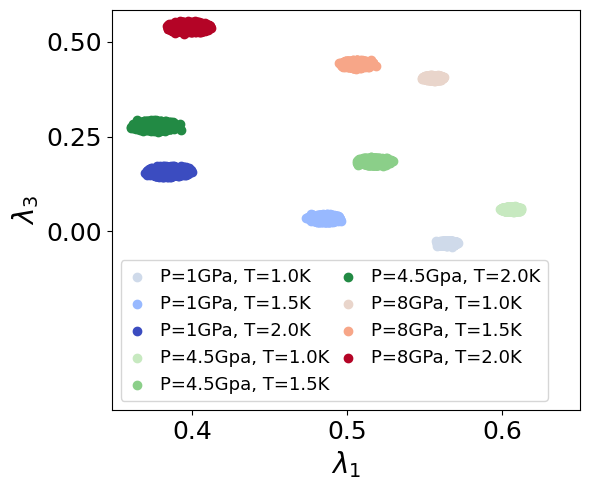

In [32]:
import matplotlib.cm as cm

# Define temperature ranges
temperature_range = [1, 2.5, 5]
# temperature_actual = np.linspace(1,5,3)#[#1, 2.5, 5]

temperature_actual = np.linspace(1,2,3)#[#1, 2.5, 5]

# Define color maps for blue and orange gradients, starting from a slightly darker level
high_cmap = cm.coolwarm(np.linspace(.55,1, 256))  # Start at 0.3 for darker blue shades
low_cmap = cm.coolwarm(np.linspace(0.45, 0, 256))  # Start at 0.3 for darker orange shades
mid_cmap = cm.Greens(np.linspace(0.25,.75, 256))  # Start at 0.3 for darker orange shades

# Normalize temperature for color mapping
norm = plt.Normalize(min(temperature_range), max(temperature_range))

gen_samples_lam1_temp = []
gen_samples_lam2_temp = []
gen_samples_lam3_temp = []

# plt.figure(figsize=(7,6))
plt.figure(figsize=(6, 5))

gen_samples_lam1_gen = temperature_gen[0]
for i, t in enumerate(temperature_range):
    gen_samples_lam1 = gen_samples_lam1_gen[i]
    color_low = low_cmap[int(norm(t) * 255)]
    plt.scatter(gen_samples_lam1[:, 0, :].mean(axis=1), gen_samples_lam1[:, 1, :].mean(axis=1), 
                label=f'P=1GPa, T={temperature_actual[i]:.1f}K', color=color_low)

gen_samples_lam3_gen = temperature_gen[2]
for i, t in enumerate(temperature_range):
    gen_samples_lam2 = gen_samples_lam2_gen[i]
    color_green = mid_cmap[int(norm(t) * 255)]
    gen_samples_lam2_temp.append(gen_samples_lam2)
    # Plot gen_samples_lam3 with the blue gradient for p=8
    plt.scatter(gen_samples_lam2[:, 0, :].mean(axis=1), gen_samples_lam2[:, 1, :].mean(axis=1), 
                label=f'P=4.5Gpa, T={temperature_actual[i]:.1f}K', color=color_green)

gen_samples_lam2_gen = temperature_gen[1]     

for i, t in enumerate(temperature_range):
    gen_samples_lam3 = gen_samples_lam3_gen[i]
    color_blue = high_cmap[int(norm(t) * 255)]
    gen_samples_lam3_temp.append(gen_samples_lam3)
    # Plot gen_samples_lam3 with the blue gradient for p=8
    plt.scatter(gen_samples_lam3[:, 0, :].mean(axis=1), gen_samples_lam3[:, 1, :].mean(axis=1), 
                label=f'P=8GPa, T={temperature_actual[i]:.1f}K', color=color_blue)


plt.xlabel(r'$\lambda_1$', fontsize=20)
plt.ylabel(r'$\lambda_3$', fontsize=20)

plt.legend(
    fontsize=13, 
    ncol=2, 
    columnspacing=0.5, 
    markerscale=1 ,
    handlelength=1 )

plt.ylim([-0.47,None])
plt.xlim([None,.65])
plt.yticks([0, 0.25, .5])  # Set y-axis ticks to 0, 0.5, and 1
plt.xticks([.4, 0.5, 0.6,])  # Set y-axis ticks to 0, 0.5, and 1
plt.tick_params(axis='both', which='major', labelsize=18)  # Set both x and y tick label sizes

plt.tight_layout()
plt.savefig('plots/figure3_d.pdf')

# Figure3 (e)

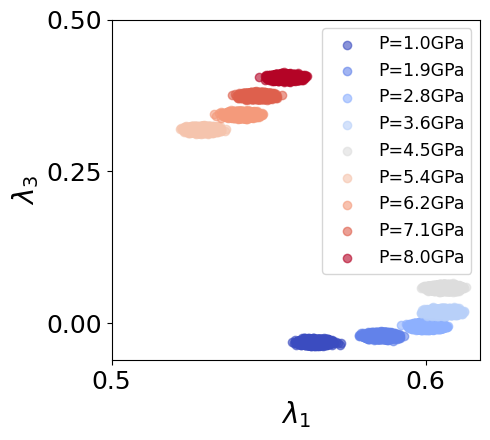

In [33]:


plt.figure(figsize=(5, 4.5))
pressure_range = [-2,-1.5, -1, -0.5,0,0.5, 1,1.5, 2]
pressure_actual = np.linspace(1,8,len(pressure_range))#[1, 2.75, 4.5, 7.25, 9]

# Define a color map (e.g., 'Blues' for blue gradient)
color_map = cm.get_cmap('coolwarm', len(pressure_range))

for i, p in enumerate(pressure_range):    
    gen_samples = gen_samples_pressure[i]
    color = color_map(i / len(pressure_range))
    plt.scatter(gen_samples[:, 0, :].mean(axis=1), gen_samples[:, 1, :].mean(axis=1),
                label=f'P={pressure_actual[i]:.1f}GPa', alpha=0.6, color=color)

plt.legend(fontsize=12.5)
plt.xlabel(r'$\lambda_1$', fontsize=20)
plt.ylabel(r'$\lambda_3$', fontsize=20)
plt.yticks([0, 0.25, .5])  # Set y-axis ticks to 0, 0.5, and 1
plt.xticks([0.5, 0.6, ])  # Set y-axis ticks to 0, 0.5, and 1
plt.tick_params(axis='both', which='major', labelsize=18)  # Set both x and y tick label sizes

plt.tight_layout()
plt.savefig('plots/figure3_e.pdf')
